# Métodos de Análisis de Datos 1
## Unidad 1: Obtención y Preparación de Datos
### Práctica - Clases 3 a 7

**Universidad Nacional del Sur**

---

## Contenido

Este notebook cubre:

1. **Carga de datos** desde diferentes fuentes
2. **Calidad de datos**: valores faltantes, duplicados, inconsistencias
3. **Transformación**: tipos, variables derivadas, codificación
4. **Normalización y estandarización**
5. **Discretización (binning)**
6. **Integración de datos** (joins)
7. **APIs REST**
8. **Tidy data y reshape**

---

## Paso 1: Carga de Datos

In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


### Crear dataset de ejemplo

Vamos a crear un dataset sintético que simula datos de empleados de una empresa.

In [3]:
# Crear dataset sintético
np.random.seed(42)
n = 200

# Datos básicos
empleados = pd.DataFrame({
    'id': range(1, n + 1),
    'nombre': [f'Empleado_{i}' for i in range(1, n + 1)],
    'edad': np.random.randint(22, 65, n),
    'departamento': np.random.choice(['IT', 'Ventas', 'RRHH', 'Finanzas', 'Marketing'], n),
    'salario': np.random.randint(30000, 120000, n),
    'fecha_ingreso': pd.date_range('2015-01-01', periods=n, freq='W'),
    'educacion': np.random.choice(['secundaria', 'universitaria', 'posgrado'], n, p=[0.2, 0.6, 0.2])
})

# Introducir problemas de calidad intencionalmente
# 1. Valores faltantes
empleados.loc[np.random.choice(empleados.index, 15, replace=False), 'edad'] = np.nan
empleados.loc[np.random.choice(empleados.index, 10, replace=False), 'salario'] = np.nan

# 2. Duplicados
empleados = pd.concat([empleados, empleados.iloc[[5, 10, 15]]], ignore_index=True)

# 3. Inconsistencias en texto
empleados.loc[20:25, 'departamento'] = empleados.loc[20:25, 'departamento'].str.lower()
empleados.loc[30:32, 'departamento'] = '  IT  '  # Espacios

# 4. Valores fuera de rango
empleados.loc[40, 'edad'] = -5
empleados.loc[41, 'edad'] = 150
empleados.loc[50, 'salario'] = -10000

print(f"Dataset creado: {empleados.shape[0]} filas, {empleados.shape[1]} columnas")
empleados.head(10)

Dataset creado: 203 filas, 7 columnas


,id,nombre,edad,departamento,salario,fecha_ingreso,educacion
0,1,Empleado_1,60.0,RRHH,83222.0,2015-01-04,posgrado
1,2,Empleado_2,50.0,RRHH,59375.0,2015-01-11,universitaria
2,3,Empleado_3,36.0,IT,39662.0,2015-01-18,universitaria
3,4,Empleado_4,64.0,Marketing,46964.0,2015-01-25,universitaria
4,5,Empleado_5,29.0,Finanzas,89638.0,2015-02-01,universitaria
5,6,Empleado_6,42.0,Ventas,NaN,2015-02-08,universitaria
6,7,Empleado_7,60.0,RRHH,115067.0,2015-02-15,secundaria
7,8,Empleado_8,40.0,IT,97215.0,2015-02-22,universitaria
8,9,Empleado_9,44.0,IT,99042.0,2015-03-01,universitaria
9,10,Empleado_10,32.0,Finanzas,43284.0,2015-03-08,posgrado


### Exploración inicial

In [4]:
# Información general
print("Información del dataset:")
empleados.info()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             203 non-null    int64         
 1   nombre         203 non-null    str           
 2   edad           187 non-null    float64       
 3   departamento   203 non-null    str           
 4   salario        192 non-null    float64       
 5   fecha_ingreso  203 non-null    datetime64[us]
 6   educacion      203 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 11.2 KB


In [5]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
empleados.describe()

Estadísticas descriptivas:


,id,edad,salario,fecha_ingreso
count,203.000000,187.000000,192.000000,203
mean,99.177340,43.550802,75855.364583,2016-11-21 05:47:35.172413
min,1.000000,-5.000000,-10000.000000,2015-01-04 00:00:00
25%,48.500000,32.000000,52709.000000,2015-12-02 12:00:00
50%,99.000000,45.000000,74343.000000,2016-11-20 00:00:00
75%,149.500000,54.000000,99143.750000,2017-11-08 12:00:00
max,200.000000,150.000000,119930.000000,2018-10-28 00:00:00
std,58.461107,15.134214,27624.526404,NaN


In [6]:
# Primeras y últimas filas
print("Primeras 5 filas:")
display(empleados.head())

print("\nÚltimas 5 filas:")
display(empleados.tail())

Primeras 5 filas:


,id,nombre,edad,departamento,salario,fecha_ingreso,educacion
0,1,Empleado_1,60.0,RRHH,83222.0,2015-01-04,posgrado
1,2,Empleado_2,50.0,RRHH,59375.0,2015-01-11,universitaria
2,3,Empleado_3,36.0,IT,39662.0,2015-01-18,universitaria
3,4,Empleado_4,64.0,Marketing,46964.0,2015-01-25,universitaria
4,5,Empleado_5,29.0,Finanzas,89638.0,2015-02-01,universitaria



Últimas 5 filas:


,id,nombre,edad,departamento,salario,fecha_ingreso,educacion
198,199,Empleado_199,NaN,IT,87799.0,2018-10-21,universitaria
199,200,Empleado_200,NaN,Marketing,43116.0,2018-10-28,universitaria
200,6,Empleado_6,42.0,Ventas,NaN,2015-02-08,universitaria
201,11,Empleado_11,32.0,RRHH,102789.0,2015-03-15,posgrado
202,16,Empleado_16,NaN,RRHH,74078.0,2015-04-19,posgrado


---

## Paso 2: Calidad de Datos

### 2.1 Valores Faltantes

In [7]:
# Detectar valores faltantes
print("Valores faltantes por columna:")
missing = empleados.isnull().sum()
missing_pct = (missing / len(empleados)) * 100

missing_df = pd.DataFrame({
    'Total': missing,
    'Porcentaje': missing_pct
})

print(missing_df[missing_df['Total'] > 0])

Valores faltantes por columna:
         Total  Porcentaje
edad        16    7.881773
salario     11    5.418719


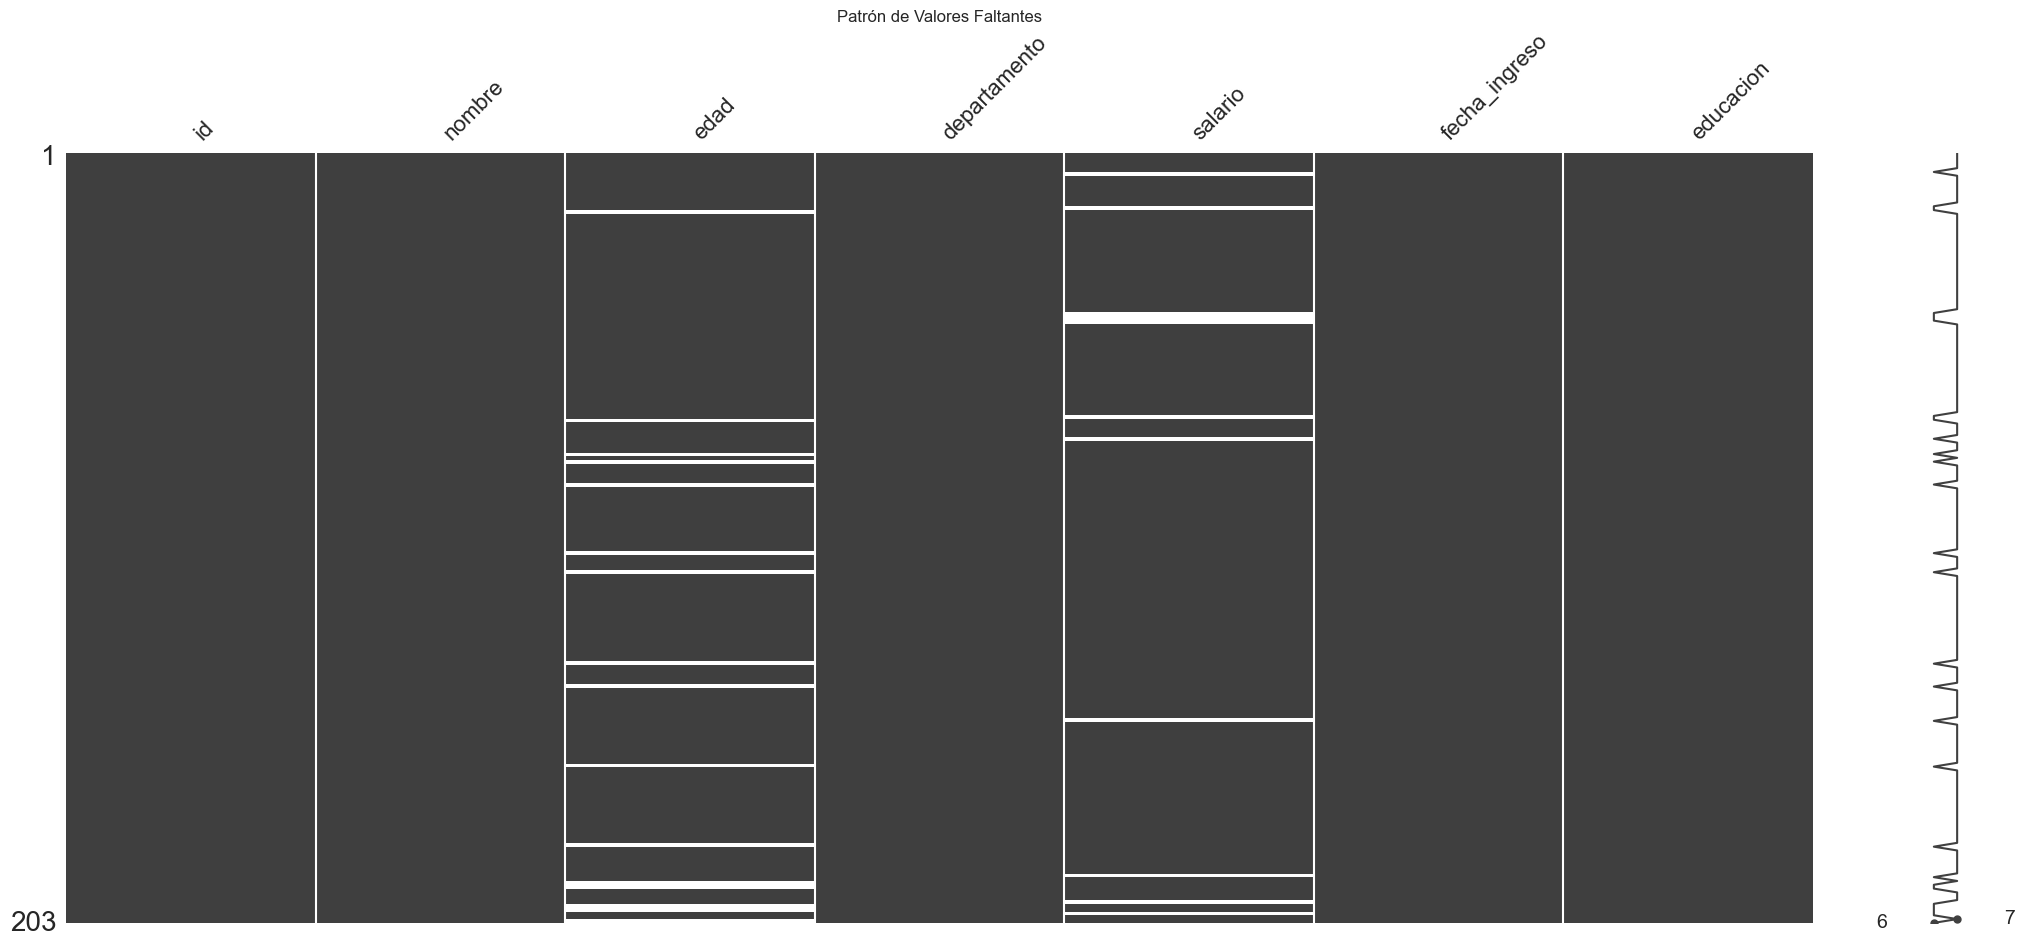

In [8]:
# Visualizar patrón de valores faltantes
import missingno as msno

msno.matrix(empleados)
plt.title('Patrón de Valores Faltantes')
plt.show()

### Estrategia de imputación

- **Edad**: Imputar con la mediana (más robusta a outliers)
- **Salario**: Imputar con la media del departamento

In [9]:
# Copiar dataset para preservar original
df = empleados.copy()

# Imputar edad con mediana
edad_mediana = df['edad'].median()
df['edad'].fillna(edad_mediana, inplace=True)
print(f"Edad: imputado {missing['edad']} valores con mediana = {edad_mediana}")

# Imputar salario con media por departamento
df['salario'] = df.groupby('departamento')['salario'].transform(
    lambda x: x.fillna(x.mean())
)
print(f"Salario: imputado {missing['salario']} valores con media por departamento")

# Verificar
print(f"\nValores faltantes después de imputación: {df.isnull().sum().sum()}")

Edad: imputado 16 valores con mediana = 45.0
Salario: imputado 11 valores con media por departamento

Valores faltantes después de imputación: 16


### 2.2 Duplicados

In [10]:
# Detectar duplicados
duplicados = df.duplicated()
print(f"Número de filas duplicadas: {duplicados.sum()}")

# Ver duplicados
if duplicados.sum() > 0:
    print("\nFilas duplicadas:")
    display(df[duplicados])

Número de filas duplicadas: 3

Filas duplicadas:


,id,nombre,edad,departamento,salario,fecha_ingreso,educacion
200,6,Empleado_6,42.0,Ventas,82496.09375,2015-02-08,universitaria
201,11,Empleado_11,32.0,RRHH,102789.00000,2015-03-15,posgrado
202,16,Empleado_16,NaN,RRHH,74078.00000,2015-04-19,posgrado


In [11]:
# Eliminar duplicados
df = df.drop_duplicates()
print(f"Dataset después de eliminar duplicados: {df.shape[0]} filas")

Dataset después de eliminar duplicados: 200 filas


### 2.3 Inconsistencias

In [12]:
# Verificar valores únicos en departamento
print("Valores únicos en departamento:")
print(df['departamento'].value_counts())

Valores únicos en departamento:
departamento
IT           43
Finanzas     42
RRHH         39
Ventas       34
Marketing    33
  IT          3
finanzas      2
it            2
rrhh          1
ventas        1
Name: count, dtype: int64


In [13]:
# Estandarizar texto: lowercase y trim
df['departamento'] = df['departamento'].str.strip().str.upper()

print("\nDespués de estandarización:")
print(df['departamento'].value_counts())


Después de estandarización:
departamento
IT           48
FINANZAS     44
RRHH         40
VENTAS       35
MARKETING    33
Name: count, dtype: int64


In [14]:
# Detectar valores fuera de rango
print("Estadísticas de edad:")
print(f"Min: {df['edad'].min()}, Max: {df['edad'].max()}")

print("\nEstadísticas de salario:")
print(f"Min: {df['salario'].min()}, Max: {df['salario'].max()}")

# Detectar valores anormales
edad_invalida = (df['edad'] < 18) | (df['edad'] > 100)
salario_invalido = df['salario'] < 0

print(f"\nEdades inválidas: {edad_invalida.sum()}")
print(f"Salarios inválidos: {salario_invalido.sum()}")

Estadísticas de edad:
Min: -5.0, Max: 150.0

Estadísticas de salario:
Min: -10000.0, Max: 119930.0

Edades inválidas: 2
Salarios inválidos: 1


In [15]:
# Corregir valores fuera de rango
# Opción 1: Reemplazar con NaN y luego imputar
df.loc[df['edad'] < 18, 'edad'] = np.nan
df.loc[df['edad'] > 100, 'edad'] = np.nan
df.loc[df['salario'] < 0, 'salario'] = np.nan

# Imputar nuevamente
df['edad'].fillna(df['edad'].median(), inplace=True)
df['salario'].fillna(df['salario'].mean(), inplace=True)

print("Valores inválidos corregidos")
print(f"Edad - Min: {df['edad'].min()}, Max: {df['edad'].max()}")
print(f"Salario - Min: {df['salario'].min()}, Max: {df['salario'].max()}")

Valores inválidos corregidos
Edad - Min: 22.0, Max: 64.0
Salario - Min: 30412.0, Max: 119930.0


---

## Paso 3: Transformación de Datos

### 3.1 Verificar y convertir tipos

In [16]:
# Verificar tipos actuales
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
id                        int64
nombre                      str
edad                    float64
departamento                str
salario                 float64
fecha_ingreso    datetime64[us]
educacion                   str
dtype: object


In [17]:
# Convertir tipos
df['id'] = df['id'].astype(str)  # ID como string
#df['edad'] = df['edad'].astype(int)  # Edad como entero
df['departamento'] = df['departamento'].astype('category')  # Categórico
df['educacion'] = pd.Categorical(
    df['educacion'],
    categories=['secundaria', 'universitaria', 'posgrado'],
    ordered=True
)  # Categórico ordenado

print("\nTipos después de conversión:")
print(df.dtypes)


Tipos después de conversión:
id                          str
nombre                      str
edad                    float64
departamento           category
salario                 float64
fecha_ingreso    datetime64[us]
educacion              category
dtype: object


### 3.2 Crear variables derivadas

In [18]:
# Extraer componentes de fecha
df['año_ingreso'] = df['fecha_ingreso'].dt.year
df['mes_ingreso'] = df['fecha_ingreso'].dt.month
df['dia_semana_ingreso'] = df['fecha_ingreso'].dt.dayofweek  # 0=Lunes

# Calcular antigüedad (en años)
hoy = pd.Timestamp.now()
df['antiguedad_años'] = (hoy - df['fecha_ingreso']).dt.days / 365.25

# Crear categorías de edad
df['categoria_edad'] = pd.cut(
    df['edad'],
    bins=[0, 30, 45, 65],
    labels=['joven', 'mediana_edad', 'senior']
)

# Salario por hora (asumiendo 40 hrs/semana, 52 semanas/año)
df['salario_por_hora'] = df['salario'] / (40 * 52)

# Es senior? (>5 años de antigüedad)
df['es_senior'] = df['antiguedad_años'] > 5

print("Variables derivadas creadas:")
print(df[['nombre', 'edad', 'categoria_edad', 'antiguedad_años', 'es_senior']].head())

Variables derivadas creadas:
       nombre  edad categoria_edad  antiguedad_años  es_senior
0  Empleado_1  60.0         senior        11.252567       True
1  Empleado_2  50.0         senior        11.233402       True
2  Empleado_3  36.0   mediana_edad        11.214237       True
3  Empleado_4  64.0         senior        11.195072       True
4  Empleado_5  29.0          joven        11.175907       True


### 3.3 Codificación de variables categóricas

In [19]:
# Label Encoding para educación (es ordinal)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['educacion_encoded'] = le.fit_transform(df['educacion'])

print("Label encoding para educación:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df[['educacion', 'educacion_encoded']].head())

Label encoding para educación:
{'posgrado': np.int64(0), 'secundaria': np.int64(1), 'universitaria': np.int64(2)}
       educacion  educacion_encoded
0       posgrado                  0
1  universitaria                  2
2  universitaria                  2
3  universitaria                  2
4  universitaria                  2


In [20]:
# One-Hot Encoding para departamento (es nominal)
df_encoded = pd.get_dummies(df, columns=['departamento'], prefix='dept')

print("\nOne-hot encoding para departamento:")
print(f"Columnas agregadas: {[col for col in df_encoded.columns if col.startswith('dept_')]}")
print(f"\nDimensiones: {df.shape} → {df_encoded.shape}")


One-hot encoding para departamento:
Columnas agregadas: ['dept_FINANZAS', 'dept_IT', 'dept_MARKETING', 'dept_RRHH', 'dept_VENTAS']

Dimensiones: (200, 15) → (200, 19)


---

## Paso 4: Normalización y Estandarización

In [21]:
# Antes de escalar, guardar copia
df_pre_scaling = df.copy()

# Seleccionar columnas numéricas para escalar
numeric_cols = ['edad', 'salario', 'antiguedad_años']

### 4.1 Min-Max Scaling

In [22]:
from sklearn.preprocessing import MinMaxScaler

# Aplicar Min-Max
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

# Comparar
print("Antes de Min-Max:")
print(df[numeric_cols].describe())

print("\nDespués de Min-Max:")
print(df_minmax[numeric_cols].describe())

Antes de Min-Max:
             edad        salario  antiguedad_años
count  183.000000     199.000000       200.000000
mean    43.306011   76207.259375         9.345654
std     12.572179   26384.056713         1.109252
min     22.000000   30412.000000         7.438741
25%     32.000000   53669.500000         8.392197
50%     45.000000   74425.000000         9.345654
75%     54.000000   97800.000000        10.299110
max     64.000000  119930.000000        11.252567

Después de Min-Max:
             edad     salario  antiguedad_años
count  183.000000  199.000000        200.00000
mean     0.507286    0.511576          0.50000
std      0.299338    0.294735          0.29085
min      0.000000    0.000000          0.00000
25%      0.238095    0.259808          0.25000
50%      0.547619    0.491666          0.50000
75%      0.761905    0.752787          0.75000
max      1.000000    1.000000          1.00000


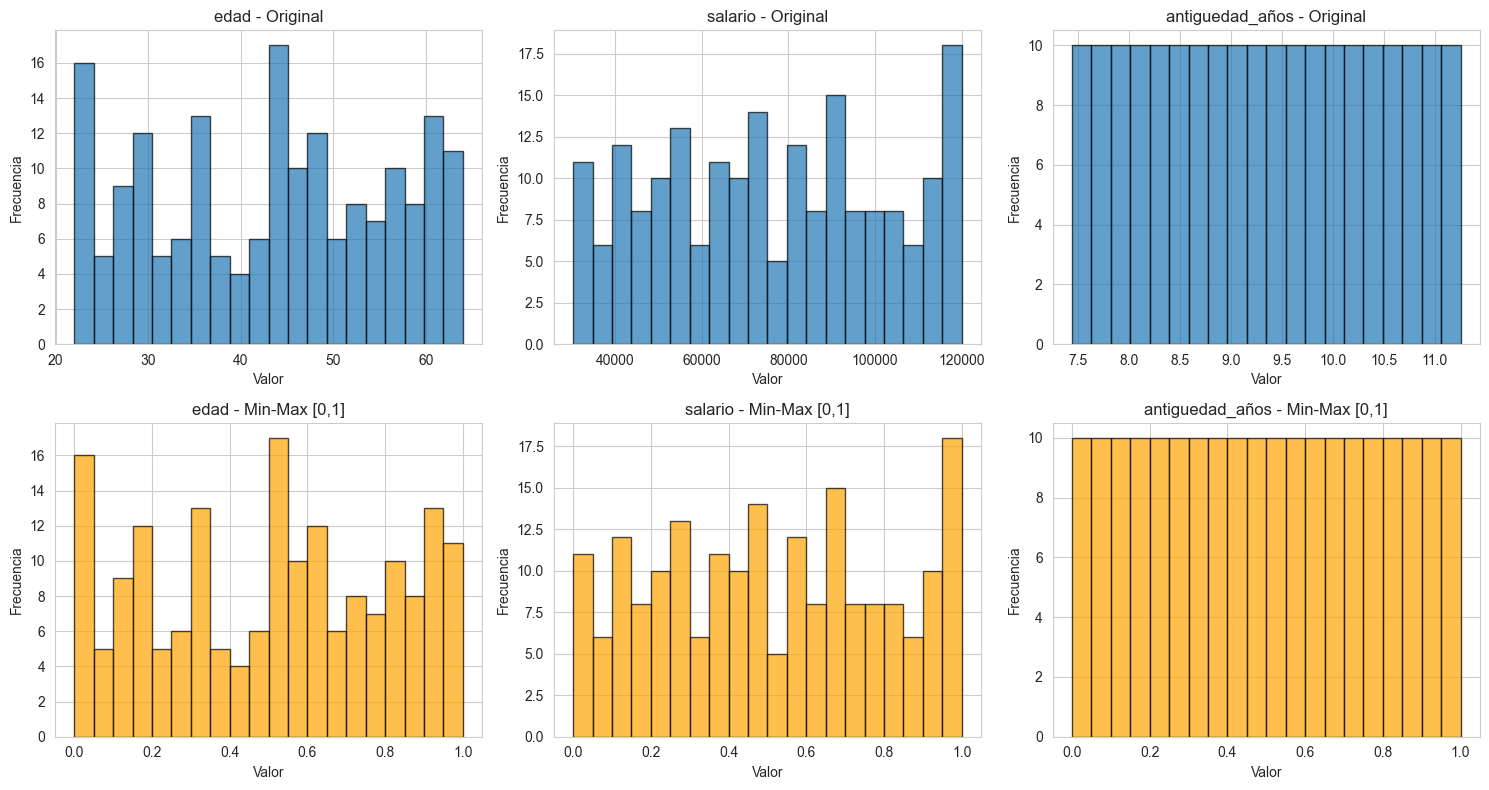

In [23]:
# Visualizar distribuciones antes y después
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    # Original
    axes[0, i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} - Original')
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')
    
    # Normalizado
    axes[1, i].hist(df_minmax[col], bins=20, edgecolor='black', alpha=0.7, color='orange')
    axes[1, i].set_title(f'{col} - Min-Max [0,1]')
    axes[1, i].set_xlabel('Valor')
    axes[1, i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 4.2 Standardization (Z-score)

In [24]:
from sklearn.preprocessing import StandardScaler

# Aplicar Standardization
scaler_std = StandardScaler()
df_std = df.copy()
df_std[numeric_cols] = scaler_std.fit_transform(df[numeric_cols])

# Comparar
print("Después de Standardization:")
print(df_std[numeric_cols].describe())
print("\nNota: Media ~0, Std ~1")

Después de Standardization:
               edad       salario  antiguedad_años
count  1.830000e+02  1.990000e+02       200.000000
mean   1.067755e-16 -2.365500e-16         0.000000
std    1.002743e+00  1.002522e+00         1.002509
min   -1.699345e+00 -1.740095e+00        -1.723412
25%   -9.017553e-01 -8.563733e-01        -0.861706
50%    1.351107e-01 -6.772099e-02         0.000000
75%    8.529411e-01  8.204652e-01         0.861706
max    1.650530e+00  1.661345e+00         1.723412

Nota: Media ~0, Std ~1


---

## Paso 5: Discretización (Binning)

In [25]:
# Bins de igual ancho
df['salario_bins_ancho'] = pd.cut(
    df['salario'],
    bins=5,
    labels=['muy_bajo', 'bajo', 'medio', 'alto', 'muy_alto']
)

print("Bins de igual ancho (salario):")
print(df['salario_bins_ancho'].value_counts().sort_index())

Bins de igual ancho (salario):
salario_bins_ancho
muy_bajo    37
bajo        40
medio       41
alto        39
muy_alto    42
Name: count, dtype: int64


In [26]:
# Bins con puntos específicos
df['salario_bins_custom'] = pd.cut(
    df['salario'],
    bins=[0, 40000, 60000, 80000, 120000],
    labels=['entrada', 'junior', 'mid', 'senior']
)

print("\nBins personalizados (salario):")
print(df['salario_bins_custom'].value_counts().sort_index())


Bins personalizados (salario):
salario_bins_custom
entrada    22
junior     43
mid        41
senior     93
Name: count, dtype: int64


In [27]:
# Bins de igual frecuencia (cuartiles)
df['salario_cuartiles'] = pd.qcut(
    df['salario'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print("\nCuartiles (salario):")
print(df['salario_cuartiles'].value_counts().sort_index())
print("\nNota: Cada cuartil tiene aproximadamente el mismo número de observaciones")


Cuartiles (salario):
salario_cuartiles
Q1    50
Q2    50
Q3    49
Q4    50
Name: count, dtype: int64

Nota: Cada cuartil tiene aproximadamente el mismo número de observaciones


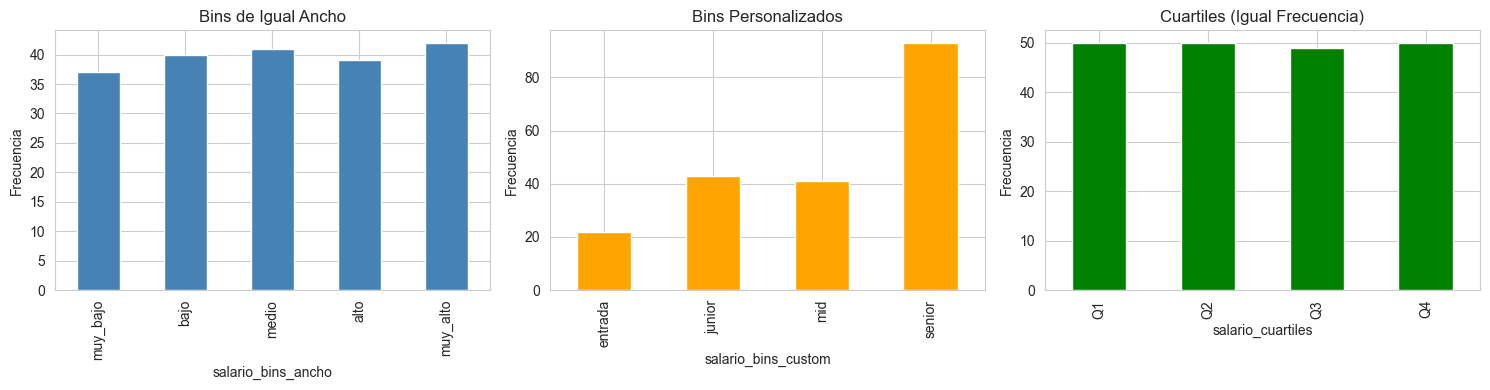

In [28]:
# Visualizar binning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['salario_bins_ancho'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Bins de Igual Ancho')
axes[0].set_ylabel('Frecuencia')

df['salario_bins_custom'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Bins Personalizados')
axes[1].set_ylabel('Frecuencia')

df['salario_cuartiles'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Cuartiles (Igual Frecuencia)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

---

## Paso 6: Integración de Datos

Vamos a crear una segunda tabla (evaluaciones de desempeño) y combinarla con la tabla de empleados.

In [29]:
# Crear tabla de evaluaciones
np.random.seed(42)

# Seleccionar IDs aleatorios (no todos los empleados tienen evaluación)
ids_evaluados = np.random.choice(df['id'].unique(), size=150, replace=False)

evaluaciones = pd.DataFrame({
    'empleado_id': ids_evaluados,
    'puntaje': np.random.randint(1, 6, 150),  # 1-5
    'fecha_evaluacion': pd.date_range('2024-01-01', periods=150, freq='D'),
    'comentarios': ['Buen desempeño' if np.random.random() > 0.5 else 'Necesita mejorar' for _ in range(150)]
})

print("Tabla de evaluaciones:")
print(evaluaciones.head())
print(f"\nShape: {evaluaciones.shape}")

Tabla de evaluaciones:
  empleado_id  puntaje fecha_evaluacion       comentarios
0          96        3       2024-01-01  Necesita mejorar
1          16        2       2024-01-02  Necesita mejorar
2          31        5       2024-01-03  Necesita mejorar
3         159        4       2024-01-04  Necesita mejorar
4         129        2       2024-01-05    Buen desempeño

Shape: (150, 4)


### 6.1 Inner Join

In [30]:
# Inner join: solo empleados con evaluación
df_inner = pd.merge(
    df,
    evaluaciones,
    left_on='id',
    right_on='empleado_id',
    how='inner'
)

print(f"Inner join: {df_inner.shape[0]} filas")
print(f"Original empleados: {df.shape[0]}, Evaluaciones: {evaluaciones.shape[0]}")
print(f"\nResultado: solo empleados que tienen evaluación")

Inner join: 150 filas
Original empleados: 200, Evaluaciones: 150

Resultado: solo empleados que tienen evaluación


### 6.2 Left Join

In [31]:
# Left join: todos los empleados, con o sin evaluación
df_left = pd.merge(
    df,
    evaluaciones,
    left_on='id',
    right_on='empleado_id',
    how='left'
)

print(f"Left join: {df_left.shape[0]} filas")
print(f"\nEmpleados sin evaluación: {df_left['puntaje'].isnull().sum()}")
print(f"Empleados con evaluación: {df_left['puntaje'].notnull().sum()}")

Left join: 200 filas

Empleados sin evaluación: 50
Empleados con evaluación: 150


In [32]:
# Ver empleados sin evaluación
sin_evaluacion = df_left[df_left['puntaje'].isnull()]
print("Empleados sin evaluación (primeros 5):")
print(sin_evaluacion[['nombre', 'departamento', 'puntaje']].head())

Empleados sin evaluación (primeros 5):
         nombre departamento  puntaje
1    Empleado_2         RRHH      NaN
8    Empleado_9           IT      NaN
13  Empleado_14     FINANZAS      NaN
14  Empleado_15     FINANZAS      NaN
17  Empleado_18         RRHH      NaN


---

## Paso 7: Acceso a APIs REST

Vamos a usar la API pública JSONPlaceholder para practicar.

In [33]:
import requests

# GET request simple
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)

if response.status_code == 200:
    usuarios = response.json()
    df_usuarios = pd.DataFrame(usuarios)
    print("Usuarios obtenidos de la API:")
    display(df_usuarios[['id', 'name', 'email', 'phone']].head())
else:
    print(f"Error: {response.status_code}")

Usuarios obtenidos de la API:


,id,name,email,phone
0,1,Leanne Graham,Sincere@april.biz,1-770-736-8031 x56442
1,2,Ervin Howell,Shanna@melissa.tv,010-692-6593 x09125
2,3,Clementine Bauch,Nathan@yesenia.net,1-463-123-4447
3,4,Patricia Lebsack,Julianne.OConner@kory.org,493-170-9623 x156
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,(254)954-1289


In [34]:
# GET con parámetros
url_posts = "https://jsonplaceholder.typicode.com/posts"
params = {'userId': 1}
response = requests.get(url_posts, params=params)

if response.status_code == 200:
    posts = response.json()
    df_posts = pd.DataFrame(posts)
    print(f"\nPosts del usuario 1: {len(df_posts)} posts")
    display(df_posts[['id', 'title']].head())


Posts del usuario 1: 10 posts


,id,title
0,1,sunt aut facere repellat provident occaecati e...
1,2,qui est esse
2,3,ea molestias quasi exercitationem repellat qui...
3,4,eum et est occaecati
4,5,nesciunt quas odio


In [35]:
# POST request (crear nuevo post)
nuevo_post = {
    'title': 'Mi nuevo post desde Python',
    'body': 'Este es el contenido de mi post',
    'userId': 1
}

response = requests.post(url_posts, json=nuevo_post)

if response.status_code == 201:
    print("\nPost creado exitosamente:")
    print(response.json())
else:
    print(f"Error: {response.status_code}")


Post creado exitosamente:
{'title': 'Mi nuevo post desde Python', 'body': 'Este es el contenido de mi post', 'userId': 1, 'id': 101}


---

## Paso 8: Tidy Data y Reshape

### 8.1 Wide → Long (Melt)

In [36]:
# Crear dataset wide de ejemplo
ventas_wide = pd.DataFrame({
    'producto': ['A', 'B', 'C'],
    '2022': [100, 150, 200],
    '2023': [120, 180, 210],
    '2024': [140, 200, 230]
})

print("Dataset WIDE (cada año es una columna):")
display(ventas_wide)

Dataset WIDE (cada año es una columna):


,producto,2022,2023,2024
0,A,100,120,140
1,B,150,180,200
2,C,200,210,230


In [37]:
# Melt: Wide → Long
ventas_long = pd.melt(
    ventas_wide,
    id_vars=['producto'],
    value_vars=['2022', '2023', '2024'],
    var_name='año',
    value_name='ventas'
)

print("\nDataset LONG (tidy):")
display(ventas_long)


Dataset LONG (tidy):


,producto,año,ventas
0,A,2022,100
1,B,2022,150
2,C,2022,200
3,A,2023,120
4,B,2023,180
5,C,2023,210
6,A,2024,140
7,B,2024,200
8,C,2024,230


### 8.2 Long → Wide (Pivot)

In [38]:
# Pivot: Long → Wide
ventas_wide_again = ventas_long.pivot(
    index='producto',
    columns='año',
    values='ventas'
)

# Reset index para tener producto como columna
ventas_wide_again = ventas_wide_again.reset_index()

print("Dataset convertido de LONG a WIDE nuevamente:")
display(ventas_wide_again)

Dataset convertido de LONG a WIDE nuevamente:


año,producto,2022,2023,2024
0,A,100,120,140
1,B,150,180,200
2,C,200,210,230


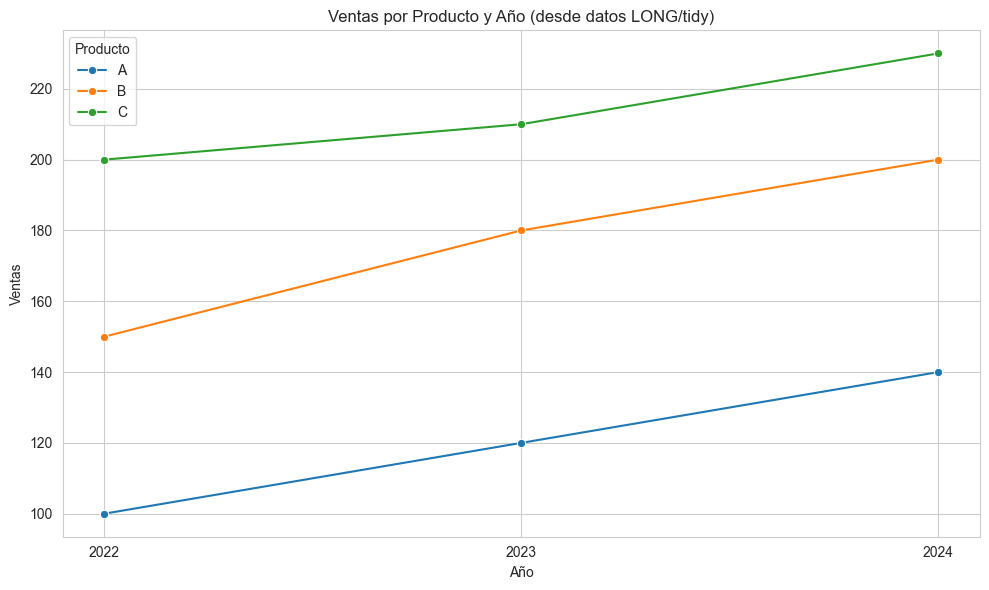

In [39]:
# Visualizar: Long es mejor para gráficos
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=ventas_long, x='año', y='ventas', hue='producto', marker='o')
plt.title('Ventas por Producto y Año (desde datos LONG/tidy)')
plt.ylabel('Ventas')
plt.xlabel('Año')
plt.legend(title='Producto')
plt.tight_layout()
plt.show()

---

## Resumen y Conclusiones

En este notebook practicamos:

### Clase 3: Fuentes de Datos y Carga
- ✓ Creación de datasets sintéticos
- ✓ Exploración inicial: `info()`, `describe()`, `head()`

### Clase 4: Calidad de Datos
- ✓ Detección de valores faltantes con `isnull()`
- ✓ Imputación simple (mediana) y por grupo (media por departamento)
- ✓ Detección y eliminación de duplicados con `drop_duplicates()`
- ✓ Estandarización de texto con `str.strip()` y `str.upper()`
- ✓ Corrección de valores fuera de rango

### Clase 5: Transformación
- ✓ Conversión de tipos: `astype()`, `pd.Categorical()`
- ✓ Variables derivadas: extraer componentes de fechas, operaciones aritméticas
- ✓ Label encoding con `LabelEncoder`
- ✓ One-hot encoding con `pd.get_dummies()`

### Clase 6: Normalización e Integración
- ✓ Min-Max scaling con `MinMaxScaler`
- ✓ Standardization con `StandardScaler`
- ✓ Discretización: `pd.cut()` (igual ancho, personalizado), `pd.qcut()` (cuartiles)
- ✓ Joins: `pd.merge()` con `how='inner'` y `how='left'`

### Clase 7: APIs y Tidy Data
- ✓ GET requests con `requests.get()`
- ✓ POST requests con `requests.post()`
- ✓ Wide → Long con `pd.melt()`
- ✓ Long → Wide con `pivot()`

### Buenas Prácticas Aplicadas
- ✓ Semilla fijada para reproducibilidad
- ✓ Copias del dataset antes de transformaciones
- ✓ Verificación en cada paso
- ✓ Visualizaciones para entender transformaciones
- ✓ Código comentado y documentado

---

## Ejercicios Propuestos

1. **Explorar otros datasets:**
   - Descargar un dataset de Kaggle
   - Aplicar todo el pipeline de preparación

2. **APIs:**
   - Usar OpenWeatherMap API (requiere API key gratuita)
   - Obtener datos del clima de varias ciudades
   - Crear DataFrame y analizar

3. **Imputación avanzada:**
   - Probar KNN imputation con `KNNImputer`
   - Comparar resultados con imputación simple

4. **Feature engineering:**
   - Crear más variables derivadas
   - Interacciones entre variables
   - Ratios y proporciones

5. **Integración compleja:**
   - Crear tercera tabla (proyectos)
   - Hacer joins múltiples
   - Analizar datos combinados